In [ ]:
%load_ext autoreload
%autoreload 2
# %matplotlib inline

import os

# to allow deterministic gradients on CUDA
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

while 'notebooks' in os.getcwd():
    os.chdir("../")

# !pwd

import torch
from torch import nn, einsum

determnistic = True
# determnistic = False  # doesn't always work with some layers
torch.use_deterministic_algorithms(determnistic)
torch.backends.cudnn.deterministic = determnistic

import quantus
import gc
import torch.nn.functional as F

from lib.helpers import plot_example_grid, make_2x2_batch_from_classes, batched_cmap_rgb, \
    squeeze_channels, normalise_by_negative_batch, as_cmap_rgb
from lib.attributions import GradientAscentDiff, PullbackAscentDiff, DoublePullbackAscentDiff, \
    quantus_pullback_ascent_diff_explain_func, quantus_double_pullback_ascent_diff_explain_func
from lib.setup import setup_notebook
from lib.defaults import get_default_kwargs
from lib.surrogates import LayerNorm2d, PVTAttention, soften_module_inplace_
from lib.evaluator import QuantusEvaluator, default_explainers, default_metrics
from lib.dataset import CLASS_NAMES


batch_size = 50
# model_name = "resnet18"
model_name = "resnet50"
# model_name = "vgg11_bn"
# model_name = "convnext_tiny"
# model_name = "efficientnet_b0"
# model_name = "densenet121"
# model_name = "vit_b_16"
model_source = "torchvision"

# model_name = "pvt_v2_b1"
# model_name = "levit_128s"
# model_name = "convit_tiny"
# model_name = "mixer_b16_224"
# model_source = "timm"

seed = 42

device, loader, model = setup_notebook(batch_size=batch_size, model_name=model_name, model_source=model_source, seed=seed)

it = iter(loader)
images, labels = next(it)

x_batch = images.numpy()
y_batch = labels.numpy()
images = images.to(device)
labels = labels.to(device)

n_show = min(15, batch_size)

# print(len(loader.dataset))
print(images.min(), images.max(), images.mean(), images.std())
print(f"images.shape = {images.shape}")
print(f"labels = {labels[:n_show].tolist()}")

plot_example_grid(images[:n_show], nrow=min(5, n_show))

In [2]:
temperatures, pga_kwargs_counterfactual, pga_kwargs_grad, pga_kwargs_adv = get_default_kwargs()

# modify the model in-place, but don't change its backward behavior
soften_module_inplace_(model, temperatures=temperatures, standard_backward=True, fill_default_temperatures=True)

gad = GradientAscentDiff(model, **pga_kwargs_counterfactual)
gad_adv = GradientAscentDiff(model, **pga_kwargs_adv)
grad = GradientAscentDiff(model, **pga_kwargs_grad)

pad = PullbackAscentDiff(model, **pga_kwargs_counterfactual)
sp = PullbackAscentDiff(model, **pga_kwargs_grad)
double_sp = DoublePullbackAscentDiff(model, pga_kwargs_1={**pga_kwargs_grad, "alpha": 2}, pga_kwargs_2=pga_kwargs_grad)

explainers = default_explainers(["SoftPullback"])
# explainers = default_explainers(["SoftPullback", "DoublePullback", "DoublePullbackBis", "Gradient"])
# metrics = default_metrics(["monotonicity_correlation", "faithfulness_correlation"])

In [3]:
xx, yy = make_2x2_batch_from_classes(images, labels, class_list=[217, 497, 566, 574])

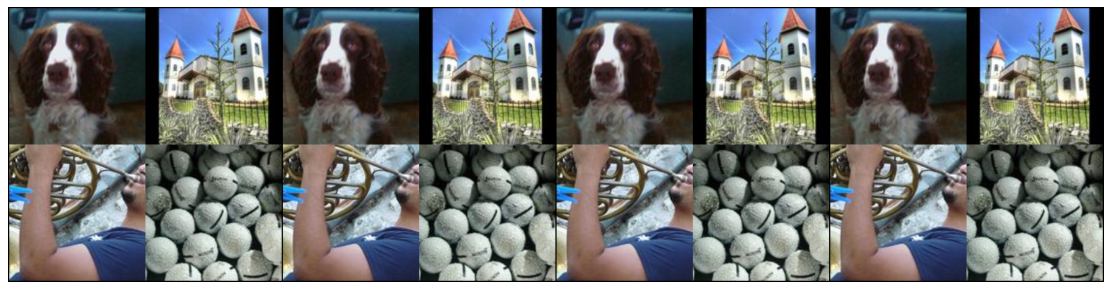

In [4]:
plot_example_grid(xx, nrow=min(5, len(xx)))

In [5]:
asp = sp.attribute(xx, yy)

In [34]:
asps = as_cmap_rgb(asp, cmap_name="seismic", mode="mean", normalise=True)
asps.shape

torch.Size([4, 3, 448, 448])

In [35]:
from lib.dataset import CLASS_NAMES
column_titles = ["Image"] + [CLASS_NAMES[c.item()][0] for c in yy]


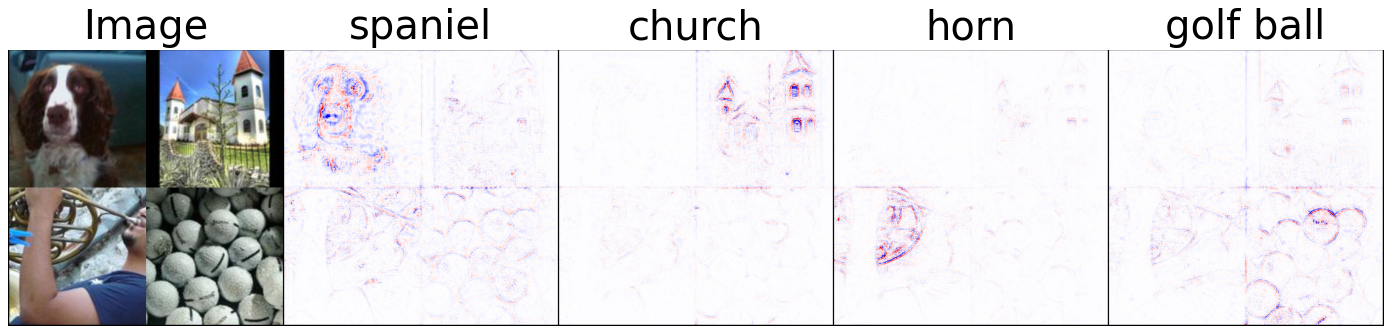

In [36]:
show = torch.cat([xx[:1].cpu(), asps], dim=0)

plot_example_grid(show, nrow=min(5, n_show), heatmap=False, dpi=80, cmap="seismic", column_titles=column_titles, fontsize=36, save_path=f"media/pointing_game_{model_name}_heat_inferno.jpg")

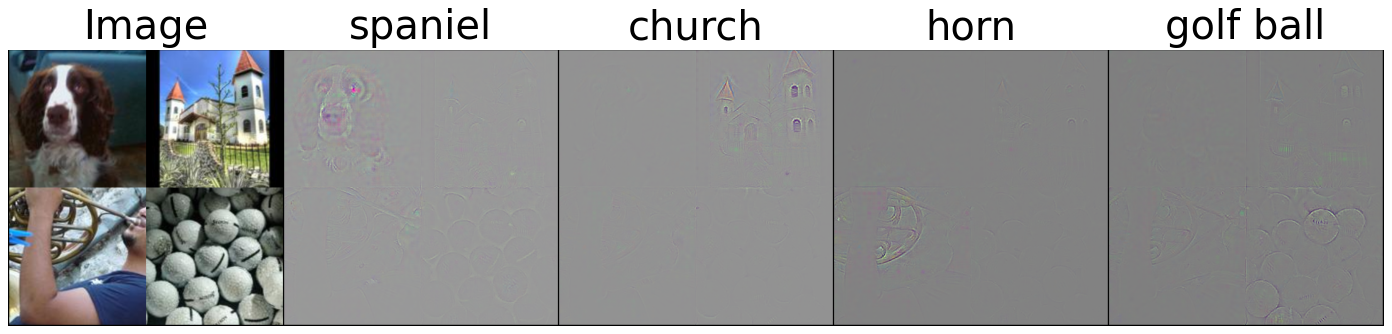

In [12]:
show = torch.cat([xx[:1], asp], dim=0)

plot_example_grid(show, nrow=min(5, n_show), heatmap=False, dpi=80, cmap="seismic", column_titles=column_titles, fontsize=36, save_path=f"media/pointing_game_{model_name}.jpg")

In [29]:
# plot_example_grid(show, nrow=min(5, 1), heatmap=False, dpi=80, cmap="seismic", row_titles=column_titles)